# 🎵 Music and Moods - The Cultural Misery Index

**Multimodal Semantic Audio Clustering × Macroeconomic Shock Correlation × GenAI Narrative Engine**

> *Does music reveal the collective psyche of a nation under economic stress?*

This notebook fuses three data streams — **Spotify streaming trends**, **Genius lyric
semantics**, and **FRED macroeconomic indicators** — to track how American music tastes
shift in response to economic pressure.

Instead of static genres, we cluster songs purely on their auditory "vibe" and lyrical
themes, then measure whether clusters like "High-Energy Melancholic Pop" expand during
inflation spikes or unemployment surges.



---
## 0. Setup & Configuration

In [1]:
# Core imports
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from IPython.display import display, Markdown

# Suppress noisy warnings for cleaner notebook output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

# Logging — set to INFO so we see pipeline progress
logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s")

# Matplotlib / Seaborn style
sns.set_theme(style="darkgrid", palette="viridis", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

print("✅ Core imports loaded")

✅ Core imports loaded


In [2]:
# CMI pipeline imports
from cmi.config import (
    AUDIO_FEATURES, DATA_RAW, DATA_PROCESSED, K_CLUSTERS,
    REGION, DATE_START, DATE_END, EMBEDDING_DIM_TARGET,
)
from cmi.ingest.spotify_charts import load_charts, get_unique_tracks
from cmi.ingest.genius_lyrics import fetch_lyrics_batch
from cmi.ingest.fred_macro import fetch_misery_index
from cmi.features.audio import extract_audio_matrix, scale_audio, audio_feature_summary
from cmi.features.embeddings import embed_lyrics
from cmi.features.fusion import reduce_embeddings, fuse_features
from cmi.clustering.temporal import cluster_temporal_windows, ClusterTimeline
from cmi.clustering.diagnostics import elbow_plot, silhouette_analysis, cluster_stability_score
from cmi.correlation.econometrics import (
    compute_volumetric_shares, rolling_correlation,
    static_correlation, granger_causality, classify_clusters,
)
from cmi.narrative.engine import (
    build_cluster_payload, generate_narrative, generate_full_report,
    generate_brief_descriptions
)

print("✅ CMI pipeline modules loaded")
print(f"   Region: {REGION}")
print(f"   Date range: {DATE_START} → {DATE_END}")
print(f"   Cluster count (K): {K_CLUSTERS}")
print(f"   Audio features: {AUDIO_FEATURES}")

✅ CMI pipeline modules loaded
   Region: us
   Date range: 2018-01-01 → 2024-12-31
   Cluster count (K): 6
   Audio features: ['danceability', 'energy', 'valence', 'acousticness', 'tempo', 'speechiness', 'instrumentalness', 'harmonic_entropy', 'timbral_variance']


---
## 1. Data Ingestion

We pull from three independent data sources, all joined on a temporal axis
(monthly intervals, 2018–2024):

1. **Spotify Charts** (Kaggle) — weekly Top 200 tracks with audio features
2. **Genius** — full lyric sheets for semantic analysis
3. **FRED** — unemployment + CPI → Okun's Misery Index

### 1.1 Spotify Chart Data (Kaggle)

Since Spotify restricted their audio features API for new apps in November 2024,
we use a pre-compiled Kaggle dataset that was built before the lockdown.

> **First time?** Run `uv run python scripts/download_kaggle_data.py` to download the data,
> or manually place a Spotify charts CSV in `data/raw/`.

In [3]:
import kagglehub
import shutil
import os

# Download the Billboard Hot 100 Audio Features dataset from Kaggle
print("📥 Downloading/resolving the Billboard Hot 100 Audio Features dataset...")
path = kagglehub.dataset_download("thedevastator/billboard-hot-100-audio-features")
print("Path to dataset files:", path)

# Copy the CSV files to data/raw/ so they are picked up by the loader
for filename in ["Hot Stuff.csv", "Hot 100 Audio Features.csv"]:
    src_file = os.path.join(path, filename)
    dest_file = DATA_RAW / filename
    if not dest_file.exists():
        print(f"Copying {filename} to {dest_file}...")
        shutil.copy(src_file, dest_file)
    else:
        print(f"{filename} already exists in {DATA_RAW}.")


📥 Downloading/resolving the Billboard Hot 100 Audio Features dataset...
Path to dataset files: /Users/sam/.cache/kagglehub/datasets/thedevastator/billboard-hot-100-audio-features/versions/1
Hot Stuff.csv already exists in /Users/sam/Locals Only/Music and Behavioral Embeddings/data/raw.
Hot 100 Audio Features.csv already exists in /Users/sam/Locals Only/Music and Behavioral Embeddings/data/raw.


In [4]:
# Find the chart CSV in data/raw/
csv_files = list(DATA_RAW.glob("*.csv"))
print(f"📂 Found {len(csv_files)} CSV files in {DATA_RAW}:")
for f in csv_files:
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"   {f.name} ({size_mb:.1f} MB)")

📂 Found 2 CSV files in /Users/sam/Locals Only/Music and Behavioral Embeddings/data/raw:
   Hot Stuff.csv (46.3 MB)
   Hot 100 Audio Features.csv (10.3 MB)


In [5]:
# Load the chart data — update the filename if your CSV is named differently
# The loader handles various Kaggle column name conventions automatically
CHART_CSV = DATA_RAW / "charts.csv"  # ← Adjust this filename to match your download

charts_df = load_charts(CHART_CSV, region=REGION, date_start=DATE_START, date_end=DATE_END)
print(f"\n📊 Chart data loaded: {charts_df.shape}")
display(charts_df.head(10))

cmi.ingest.spotify_charts | Loading Billboard charts from /Users/sam/Locals Only/Music and Behavioral Embeddings/data/raw/Hot Stuff.csv
cmi.ingest.spotify_charts | Loading audio features from /Users/sam/Locals Only/Music and Behavioral Embeddings/data/raw/Hot 100 Audio Features.csv
cmi.ingest.spotify_charts | Merging charts with audio features...
cmi.ingest.spotify_charts | Merged shape: (327817, 33)
cmi.ingest.spotify_charts | Date-filtered to 2018-01-01 – 2024-12-31: 17747 rows
cmi.ingest.spotify_charts | Missing audio features in dataset: ['harmonic_entropy', 'timbral_variance']
cmi.ingest.spotify_charts | Deduplicated: 17747 → 17744 rows
cmi.ingest.spotify_charts | Final chart data shape: (17744, 37)



📊 Chart data loaded: (17744, 37)


,index_x,url,date,rank,title,artist,SongID,Instance,Previous Week Position,Peak Position,...,instrumentalness,liveness,valence,tempo,time_signature,spotify_track_popularity,track_id,region,streams,year_month
0,300674,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,1,Perfect,Ed Sheeran,PerfectEd Sheeran,2,1.0,1,...,0.000000,0.1060,0.168,95.050,3.0,88.0,0tgVpDi06FyKpA1z0VMD4v,us,0,2018-01
1,194901,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,2,Rockstar,Post Malone Featuring 21 Savage,RockstarPost Malone Featuring 21 Savage,1,2.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,RockstarPost Malone Featuring 21 Savage,us,0,2018-01
2,283331,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,3,Havana,Camila Cabello Featuring Young Thug,HavanaCamila Cabello Featuring Young Thug,2,3.0,2,...,0.000036,0.1320,0.394,104.988,4.0,86.0,1rfofaqEpACxVEHIZBJe6W,us,0,2018-01
3,311418,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,4,No Limit,G-Eazy Featuring A$AP Rocky & Cardi B,No LimitG-Eazy Featuring A$AP Rocky & Cardi B,1,5.0,4,...,0.000000,0.0853,0.405,175.957,4.0,78.0,2DQ1ITjI0YoLFzuADN1ZBW,us,0,2018-01
4,86090,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,5,Thunder,Imagine Dragons,ThunderImagine Dragons,1,6.0,4,...,0.134000,0.1470,0.288,167.997,4.0,87.0,1zB4vmk8tFRmM9UULNzbLB,us,0,2018-01
5,311511,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,6,Gucci Gang,Lil Pump,Gucci GangLil Pump,1,4.0,3,...,0.000000,0.1170,0.699,119.889,4.0,76.0,43ZyHQITOjhciSUUNPVRHc,us,0,2018-01
6,212271,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,7,MotorSport,"Migos, Nicki Minaj & Cardi B","MotorSportMigos, Nicki Minaj & Cardi B",1,7.0,6,...,0.000000,0.3170,0.174,138.016,4.0,77.0,4wFjTWCunQFKtukqrNijEt,us,0,2018-01
7,123450,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,8,Too Good At Goodbyes,Sam Smith,Too Good At GoodbyesSam Smith,1,8.0,4,...,0.000000,0.1770,0.523,91.500,4.0,78.0,3VlbOrM6nYPprVvzBZllE5,us,0,2018-01
8,262808,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,9,Bad At Love,Halsey,Bad At LoveHalsey,1,10.0,8,...,0.000000,0.0893,0.612,118.384,4.0,79.0,7y9iMe8SOB6z3NoHE2OfXl,us,0,2018-01
9,273270,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,10,Bodak Yellow (Money Moves),Cardi B,Bodak Yellow (Money Moves)Cardi B,1,12.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Bodak Yellow (Money Moves)Cardi B,us,0,2018-01


In [6]:
# Quick data quality check
print("Column dtypes:")
print(charts_df.dtypes)
print(f"\nDate range: {charts_df['date'].min()} → {charts_df['date'].max()}")
print(f"Unique tracks: {charts_df['title'].nunique() if 'title' in charts_df.columns else 'N/A'}")
print(f"Unique months: {charts_df['year_month'].nunique() if 'year_month' in charts_df.columns else 'N/A'}")

# Audio feature coverage
for feat in AUDIO_FEATURES:
    if feat in charts_df.columns:
        null_pct = charts_df[feat].isna().mean() * 100
        print(f"   {feat}: {null_pct:.1f}% null")

Column dtypes:
index_x                               int64
url                                     str
date                         datetime64[us]
rank                                  int64
title                                   str
artist                                  str
SongID                                  str
Instance                              int64
Previous Week Position              float64
Peak Position                         int64
Weeks on Chart                        int64
index_y                               int64
Performer_y                             str
Song_y                                  str
spotify_genre                           str
spotify_track_id                        str
spotify_track_preview_url               str
spotify_track_duration_ms           float64
spotify_track_explicit               object
spotify_track_album                     str
danceability                        float64
energy                              float64
key              

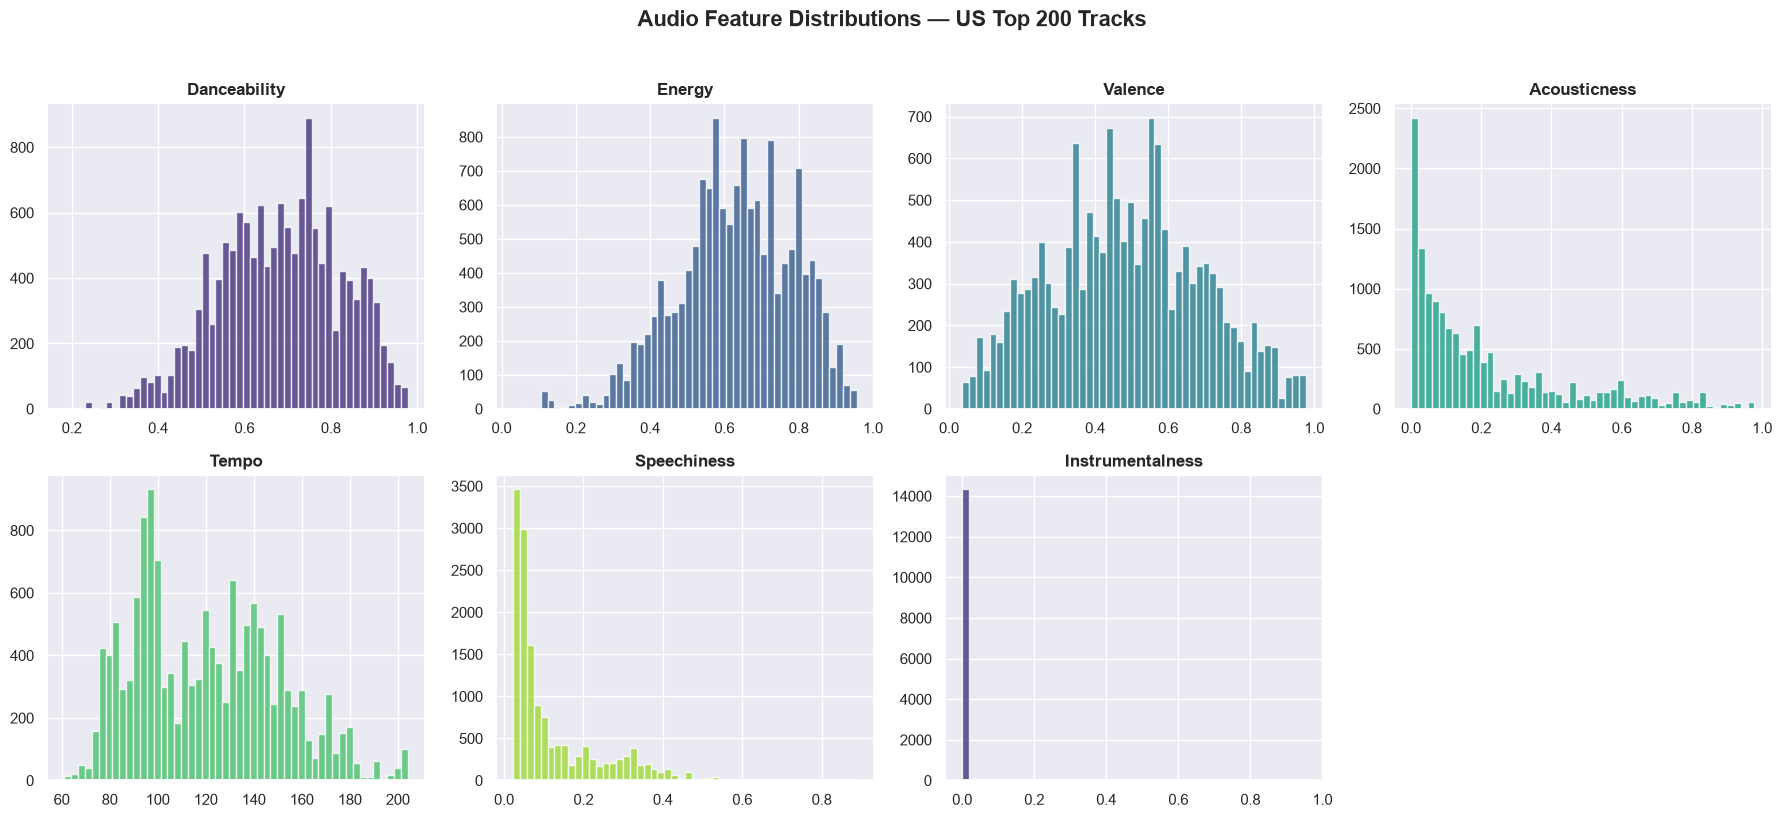

In [7]:
# Audio feature distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
available_feats = [f for f in AUDIO_FEATURES if f in charts_df.columns]

for i, feat in enumerate(available_feats):
    ax = axes.flat[i]
    charts_df[feat].dropna().hist(bins=50, ax=ax, color=sns.color_palette("viridis")[i % 6], alpha=0.8)
    ax.set_title(feat.title(), fontweight="bold")
    ax.set_xlabel("")

# Hide unused subplots
for j in range(len(available_feats), len(axes.flat)):
    axes.flat[j].set_visible(False)

plt.suptitle("Audio Feature Distributions — US Top 200 Tracks", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 1.2 FRED Macroeconomic Data — The Misery Index

Arthur Okun's **Misery Index** = Unemployment Rate + Year-over-Year Inflation.
When it spikes, people are hurting. We use this as our measure of economic stress.

> **Key events in our window:**
> - 2020 Q1–Q2: COVID-19 shock (unemployment spike to 14.7%)
> - 2021–2022: Post-COVID inflation surge
> - 2022 H2: Fed rate hikes, inflation cooling

In [8]:
# Fetch economic data from FRED
misery_df = fetch_misery_index()
print(f"📈 Misery Index: {len(misery_df)} monthly observations")
display(misery_df.head(10))

cmi.ingest.fred_macro | Fetching UNRATE from FRED (2018-01-01 to 2024-12-31)...
cmi.ingest.fred_macro | Fetching CPIAUCSL from FRED (2018-01-01 to 2024-12-31)...
cmi.ingest.fred_macro | Misery Index computed: 72 months, range 5.2 – 15.1


📈 Misery Index: 72 monthly observations


,date,unemployment_rate,cpi,yoy_inflation,misery_index
0,2019-01-01,4.0,252.561,1.487589,5.487589
1,2019-02-01,3.8,253.319,1.518862,5.318862
2,2019-03-01,3.8,254.277,1.883186,5.683186
3,2019-04-01,3.7,255.233,2.000583,5.700583
4,2019-05-01,3.6,255.296,1.795911,5.395911
5,2019-06-01,3.6,255.213,1.671195,5.271195
6,2019-07-01,3.7,255.802,1.826331,5.526331
7,2019-08-01,3.6,256.036,1.737641,5.337641
8,2019-09-01,3.5,256.430,1.684498,5.184498
9,2019-10-01,3.6,257.155,1.733974,5.333974


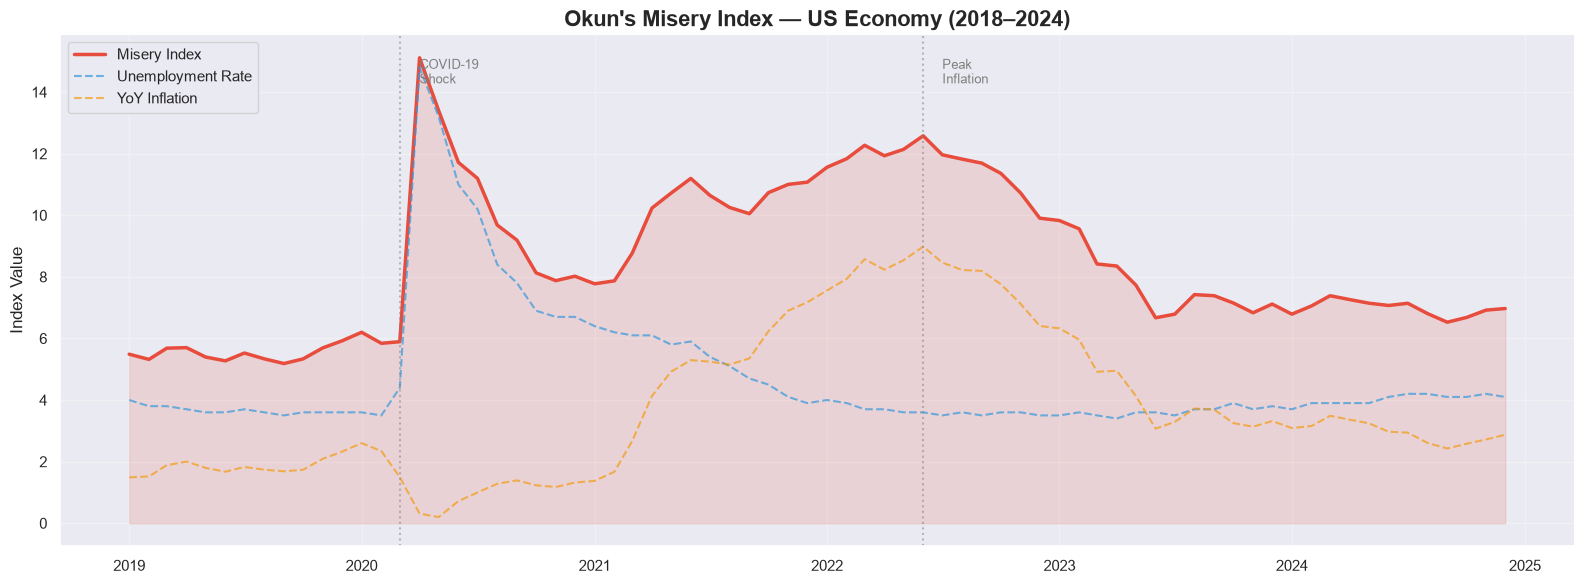

In [9]:
# Plot the Misery Index with key events annotated
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(misery_df["date"], misery_df["misery_index"], linewidth=2.5, color="#e74c3c", label="Misery Index")
ax.fill_between(misery_df["date"], misery_df["misery_index"], alpha=0.15, color="#e74c3c")

# Component breakdown
ax.plot(misery_df["date"], misery_df["unemployment_rate"], "--", linewidth=1.5, color="#3498db", alpha=0.7, label="Unemployment Rate")
ax.plot(misery_df["date"], misery_df["yoy_inflation"], "--", linewidth=1.5, color="#f39c12", alpha=0.7, label="YoY Inflation")

# Annotate key events
ax.axvline(pd.Timestamp("2020-03-01"), color="gray", linestyle=":", alpha=0.5)
ax.text(pd.Timestamp("2020-04-01"), ax.get_ylim()[1] * 0.9, "COVID-19\nShock", fontsize=9, color="gray")

ax.axvline(pd.Timestamp("2022-06-01"), color="gray", linestyle=":", alpha=0.5)
ax.text(pd.Timestamp("2022-07-01"), ax.get_ylim()[1] * 0.9, "Peak\nInflation", fontsize=9, color="gray")

ax.set_title("Okun's Misery Index — US Economy (2018–2024)", fontsize=16, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Index Value", fontsize=12)
ax.legend(loc="upper left", fontsize=11)
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

### 1.3 Genius Lyrics

We fetch full lyric sheets for every unique track in our chart data.
The Genius API is rate-limited, so this step caches results to disk
and uses a 1.5-second delay between requests.

> ⏱️ **First run warning**: Fetching lyrics for ~2,000+ unique tracks takes
> approximately 1-2 hours due to rate limiting. Results are cached in
> `data/raw/lyrics_cache/` so subsequent runs are instant.

In [10]:
# Get unique tracks for lyrics fetching
unique_tracks = get_unique_tracks(charts_df)
print(f"🎤 Unique tracks to fetch lyrics for: {len(unique_tracks)}")
display(unique_tracks.head(10))

# Fetch lyrics (incremental — checks existing csv, disk cache, then Genius API)
# ⚠️ SLOW on first run if many tracks are uncached.
lyrics_df_path = DATA_PROCESSED / "tracks_with_lyrics.csv"

if lyrics_df_path.exists():
    print("⏳ Loading existing tracks with lyrics from disk...")
    existing_df = pd.read_csv(lyrics_df_path)
    # Deduplicate existing_df by track_id
    existing_df = existing_df.drop_duplicates(subset=["track_id"])
    
    # Identify which unique_tracks are missing from existing_df
    missing_mask = ~unique_tracks["track_id"].isin(existing_df["track_id"])
    missing_tracks = unique_tracks[missing_mask].copy()
    
    if len(missing_tracks) > 0:
        print(f"🎤 Found {len(missing_tracks)} new tracks not in tracks_with_lyrics.csv.")
        print("⏳ Fetching lyrics for new tracks (using Genius API / local cache)...")
        new_lyrics_df = fetch_lyrics_batch(missing_tracks)
        
        # Combine existing and new
        combined_df = pd.concat([existing_df, new_lyrics_df], ignore_index=True)
    else:
        print("✅ All current unique tracks already exist in tracks_with_lyrics.csv.")
        combined_df = existing_df
else:
    print("⏳ No tracks_with_lyrics.csv found. Fetching lyrics for all unique tracks...")
    combined_df = fetch_lyrics_batch(unique_tracks)

# Save the updated tracks_with_lyrics back to disk
combined_df.to_csv(lyrics_df_path, index=False)
print(f"💾 Saved updated tracks with lyrics to: {lyrics_df_path}")

# Align tracks_with_lyrics to contain exactly the unique_tracks for the current charts_df
tracks_with_lyrics = unique_tracks.merge(combined_df[["track_id", "lyrics"]], on="track_id", how="left")

# Ensure NaN/missing lyrics are represented as None/object for processing
tracks_with_lyrics["lyrics"] = tracks_with_lyrics["lyrics"].where(tracks_with_lyrics["lyrics"].notna(), None)

lyrics_found = tracks_with_lyrics["lyrics"].notna().sum()
print(f"\n✅ Lyrics found in current set: {lyrics_found} / {len(tracks_with_lyrics)} ({100*lyrics_found/len(tracks_with_lyrics):.1f}%)")

# Preview a sample
sample = tracks_with_lyrics[tracks_with_lyrics["lyrics"].notna()].head(3)
for _, row in sample.iterrows():
    print(f"\n🎵 {row['title']} — {row['artist']}")
    print(f"   {row['lyrics'][:200]}...")

cmi.ingest.spotify_charts | Unique tracks: 2136


🎤 Unique tracks to fetch lyrics for: 2136


,track_id,title,artist,danceability,energy,valence,acousticness,tempo,speechiness,instrumentalness
0,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,0.353,0.755,0.437,0.0822,191.153,0.7330,0.000000
1,00B7TZ0Xawar6NZ00JFomN,Best Life,Cardi B Featuring Chance The Rapper,0.620,0.625,0.665,0.2870,167.911,0.5530,0.000000
2,00ko9WaS4jOX1kEk3gvHjf,Hot Shower,Chance The Rapper Featuring MadeinTYO & DaBaby,0.897,0.522,0.623,0.0016,149.986,0.3740,0.000000
3,017PF4Q3l4DBUiWoXk4OWT,Break My Heart,Dua Lipa,0.730,0.729,0.467,0.1670,113.013,0.0883,0.000001
4,01FvQEvHETjWqcDpQDJdTb,Your Bartender,Morgan Wallen,0.555,0.771,0.442,0.2470,139.971,0.0282,0.000073
5,01TnVDiet1DFTsyWKUKovl,Numb,XXXTENTACION,0.414,0.416,0.196,0.1000,159.910,0.0251,0.179000
6,01jIO8SJFnpSiNLH1JaBZ5,You,Jacquees,0.735,0.453,0.335,0.4130,115.002,0.0602,0.000000
7,01z2fBGB8Hl3Jd3zXe4IXR,Come Back To Earth,Mac Miller,0.272,0.238,0.119,0.8900,83.507,0.0349,0.009250
8,02FaKXXL7KUtRc7K0k54tL,Cozy Little Christmas,Katy Perry,0.774,0.608,0.560,0.1280,137.494,0.1280,0.000000
9,03B2SfXuvDh1m9F4tqrX07,Skin,Sabrina Carpenter,0.557,0.457,0.328,0.4280,105.918,0.0335,0.000000


⏳ Loading existing tracks with lyrics from disk...
✅ All current unique tracks already exist in tracks_with_lyrics.csv.
💾 Saved updated tracks with lyrics to: /Users/sam/Locals Only/Music and Behavioral Embeddings/data/processed/tracks_with_lyrics.csv

✅ Lyrics found in current set: 2111 / 2136 (98.8%)

🎵 Growing Pains — Alessia Cara
   You're on your own, kid
You are

Make my way through the motions, I try to ignore it
But home's looking farther the closer I get
Don't know why I can't see the end
Is it over yet? Hmm
A short leash an...

🎵 Best Life — Cardi B Featuring Chance The Rapper
   I'm livin' my best life, yeah, yeah
I'm livin' my best life (Best life)
Made a couple M's, you know (Ah! Huh!)

Said I'm livin' my best life
Said I'm livin' my best life
Made a couple M's with my best...

🎵 Hot Shower — Chance The Rapper Featuring MadeinTYO & DaBaby
   HIGHEST IN THE ROOM - Travis Scott
Bandit - Juice WRLD and YoungBoy Never Broke Again
Camelot - NLE Choppa
VIBEZ - DaBaby
223's - YNW

### 1.4 Raw Audio Complexity Feature Engineering (Spotify API)

We tap into the raw audio analysis endpoint to fetch chroma (pitch) and timbre
vectors. We calculate:
- **Harmonic Entropy**: a measure of chord complexity and predictability.
- **Timbral Variance**: standard deviation of timbre coefficients over time (roughness/compression).

If no Spotify credentials are set in `.env`, it defaults to offline fallback baselines.

In [11]:
from cmi.features.audio_analysis import fetch_audio_complexity_batch

complexity_df = fetch_audio_complexity_batch(unique_tracks)
print(f"\n✅ Audio complexity features calculated: {complexity_df.shape}")
display(complexity_df.head(10))

# Merge complexity features back into unique_tracks and tracks_with_lyrics
unique_tracks = unique_tracks.merge(complexity_df, on="track_id", how="left")
tracks_with_lyrics = tracks_with_lyrics.merge(complexity_df, on="track_id", how="left")

cmi.features.audio_analysis | Loading pre-compiled Spotify preview URLs from Hot 100 Audio Features.csv
Analyzing audio complexity (local librosa): 100%|██████████| 2136/2136 [00:00<00:00, 4008.31it/s]


✅ Audio complexity features calculated: (2136, 3)


,track_id,harmonic_entropy,timbral_variance
0,003eoIwxETJujVWmNFMoZy,3.2177,573.0013
1,00B7TZ0Xawar6NZ00JFomN,3.1989,760.4509
2,00ko9WaS4jOX1kEk3gvHjf,3.2908,1331.3763
3,017PF4Q3l4DBUiWoXk4OWT,3.2341,456.2388
4,01FvQEvHETjWqcDpQDJdTb,3.3253,397.9500
5,01TnVDiet1DFTsyWKUKovl,3.3880,311.6906
6,01jIO8SJFnpSiNLH1JaBZ5,3.1524,801.5151
7,01z2fBGB8Hl3Jd3zXe4IXR,3.2708,458.9486
8,02FaKXXL7KUtRc7K0k54tL,3.2464,905.1126
9,03B2SfXuvDh1m9F4tqrX07,3.1280,247.6362


---
## 2. Feature Engineering — Multimodal Fusion

This is where the magic happens. We combine two fundamentally different
representations of each song:

1. **Audio features** (7D): What it *sounds* like — tempo, energy, valence, etc.
2. **Lyric embeddings** (768D → 10D): What it *says* — dense semantic vectors

The challenge: raw 768D embeddings would dominate the 7 audio features in any
distance metric. We use **UMAP** to compress lyrics to ~10 dimensions, preserving
macro themes (isolation vs. partying vs. heartbreak) without overwhelming the audio.

### 2.1 Lyric Embedding via Google Gemini

In [12]:
# Filter to tracks that have lyrics
tracks_with_text = tracks_with_lyrics[tracks_with_lyrics["lyrics"].notna()].copy()
lyrics_list = tracks_with_text["lyrics"].tolist()
track_ids = tracks_with_text["track_id"].tolist()

embeddings_cache_path = DATA_PROCESSED / "lyric_embeddings.npy"
embedding_map = {}

# Load existing embeddings and build a map of track_id -> embedding vector
# We map them by aligning with the prefix of tracks_with_lyrics.csv
lyrics_df_path = DATA_PROCESSED / "tracks_with_lyrics.csv"
if embeddings_cache_path.exists() and lyrics_df_path.exists():
    print("⏳ Loading existing lyric embeddings and mapping them to track_ids...")
    try:
        old_embeddings = np.load(embeddings_cache_path)
        old_lyrics_df = pd.read_csv(lyrics_df_path)
        # Old embeddings correspond 1-to-1 to the first N non-null lyric rows in old_lyrics_df
        old_tracks_with_text = old_lyrics_df[old_lyrics_df["lyrics"].notna()].copy()
        n_embeddings = len(old_embeddings)
        
        if len(old_tracks_with_text) >= n_embeddings:
            for idx in range(n_embeddings):
                row = old_tracks_with_text.iloc[idx]
                embedding_map[row["track_id"]] = old_embeddings[idx]
            print(f"✅ Mapped {n_embeddings} existing embeddings from disk using prefix alignment.")
        else:
            print(f"⚠️ Embedding count mismatch (expected >= {n_embeddings} tracks, found {len(old_tracks_with_text)}). Re-building map...")
    except Exception as e:
        print(f"⚠️ Could not load existing embedding map: {e}")

# Build embedding matrix for current tracks
current_embeddings = []
tracks_to_embed = []
indices_to_embed = []

for idx, tid in enumerate(track_ids):
    if tid in embedding_map:
        current_embeddings.append(embedding_map[tid])
    else:
        current_embeddings.append(None)
        tracks_to_embed.append(lyrics_list[idx])
        indices_to_embed.append(idx)

if len(tracks_to_embed) > 0:
    print(f"📝 Embedding {len(tracks_to_embed)} new lyric texts via gemini-embedding-001...")
    new_embeddings = embed_lyrics(tracks_to_embed)
    
    # Store new embeddings in map and update current list
    for idx, emb_vector in zip(indices_to_embed, new_embeddings):
        tid = track_ids[idx]
        embedding_map[tid] = emb_vector
        current_embeddings[idx] = emb_vector
else:
    print("✅ All required lyric embeddings retrieved from cache.")

# Construct the final aligned embedding matrix
lyric_embeddings = np.vstack(current_embeddings)
print(f"   Embedding matrix: {lyric_embeddings.shape}")

# Save the updated embedding map back to disk in the original layout matching tracks_with_lyrics.csv
# So that subsequent runs or downstream code remains aligned with tracks_with_lyrics.csv.
full_lyrics_df = pd.read_csv(lyrics_df_path)
full_tracks_with_text = full_lyrics_df[full_lyrics_df["lyrics"].notna()].copy()

saved_embeddings = []
for _, row in full_tracks_with_text.iterrows():
    tid = row["track_id"]
    if tid in embedding_map:
        saved_embeddings.append(embedding_map[tid])
    else:
        # Fallback in case a track in tracks_with_lyrics has lyrics but no embedding yet
        print(f"⚠️ Embedding missing for cached track {tid}. Embedding it now...")
        emb_vector = embed_lyrics([row["lyrics"]])[0]
        embedding_map[tid] = emb_vector
        saved_embeddings.append(emb_vector)

if saved_embeddings:
    np.save(embeddings_cache_path, np.vstack(saved_embeddings))
    print(f"💾 Saved {len(saved_embeddings)} embeddings to: {embeddings_cache_path}")

⏳ Loading existing lyric embeddings and mapping them to track_ids...
✅ Mapped 2684 existing embeddings from disk using prefix alignment.
✅ All required lyric embeddings retrieved from cache.
   Embedding matrix: (2111, 3072)
💾 Saved 2684 embeddings to: /Users/sam/Locals Only/Music and Behavioral Embeddings/data/processed/lyric_embeddings.npy


### 2.2 Dimensionality Reduction (UMAP)

cmi.features.fusion | Reducing embeddings from 3072D → 10D via UMAP
cmi.features.fusion | Reduced embedding shape: (2111, 10)
cmi.features.fusion | Reducing embeddings from 3072D → 2D via UMAP


📉 Reduced lyrics: (2111, 10)


cmi.features.fusion | Reduced embedding shape: (2111, 2)


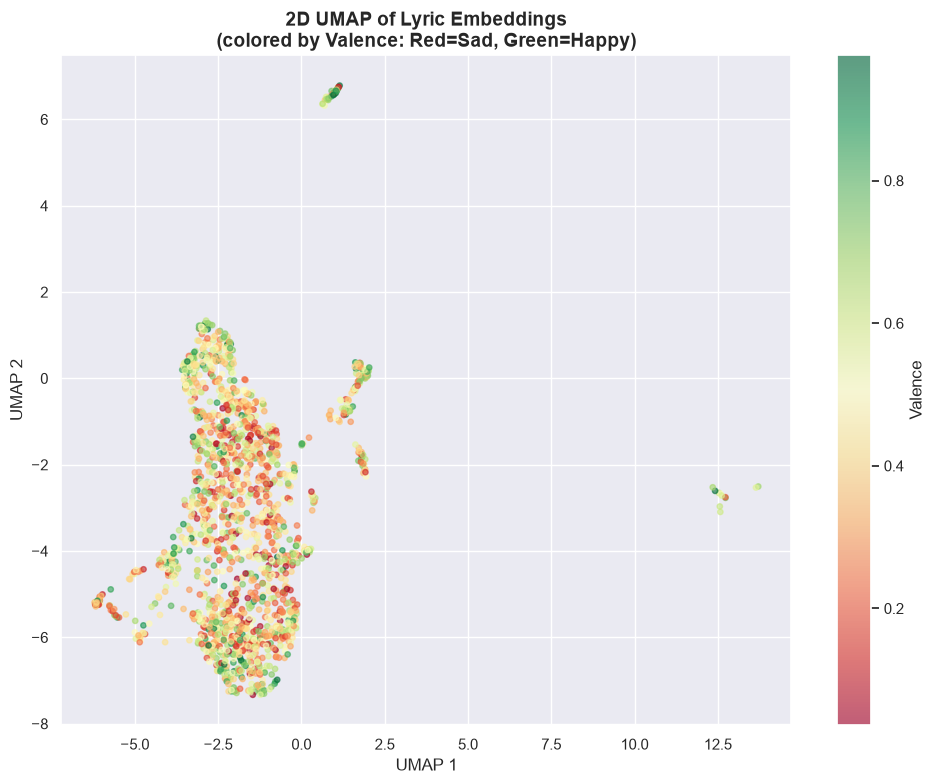

In [13]:
# UMAP: 768D → 10D
reduced_lyrics = reduce_embeddings(lyric_embeddings, n_components=EMBEDDING_DIM_TARGET)
print(f"📉 Reduced lyrics: {reduced_lyrics.shape}")

# Visualize the 2D UMAP projection for intuition
umap_2d = reduce_embeddings(lyric_embeddings, n_components=2)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    umap_2d[:, 0], umap_2d[:, 1],
    c=tracks_with_text["valence"].values if "valence" in tracks_with_text.columns else "steelblue",
    cmap="RdYlGn", alpha=0.6, s=15,
)
ax.set_title("2D UMAP of Lyric Embeddings\n(colored by Valence: Red=Sad, Green=Happy)", fontsize=14, fontweight="bold")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.colorbar(scatter, label="Valence", ax=ax)
plt.tight_layout()
plt.show()

### 2.3 Audio Feature Extraction & Fusion

In [14]:
# Extract and scale audio features for tracks WITH lyrics
audio_matrix = extract_audio_matrix(tracks_with_text)
print(f"🔊 Audio matrix: {audio_matrix.shape}")

# Fuse: audio (7D) + reduced lyrics (10D) → 17D, StandardScaled
fused_matrix, fused_scaler = fuse_features(audio_matrix, reduced_lyrics)
print(f"🔗 Fused matrix: {fused_matrix.shape}")
print(f"   Feature dimensions: {audio_matrix.shape[1]} audio + {reduced_lyrics.shape[1]} lyric = {fused_matrix.shape[1]} total")

cmi.features.audio | Audio matrix shape: (2111, 9)
cmi.features.fusion | Fused matrix: 9 audio + 10 lyric = 19D total
cmi.features.fusion | Fused & scaled matrix shape: (2111, 19)


🔊 Audio matrix: (2111, 9)
🔗 Fused matrix: (2111, 19)
   Feature dimensions: 9 audio + 10 lyric = 19 total


---
## 3. Temporal Clustering — Tracking Vibe Archetypes Over Time

Instead of clustering all songs at once (which would hide temporal dynamics),
we cluster within **monthly time windows** and use the **Hungarian Algorithm**
to maintain consistent cluster identities across months.

The label-switching problem: K-Means assigns arbitrary labels each run.
"High-Energy Melancholic Pop" might be Cluster 2 in January but Cluster 5
in February. The Hungarian algorithm finds the optimal 1-to-1 mapping between
old and new centroids based on Euclidean distance.

### 3.1 Optimal K Selection

📊 Running yellowbrick KElbowVisualizer to auto-detect elbow value...


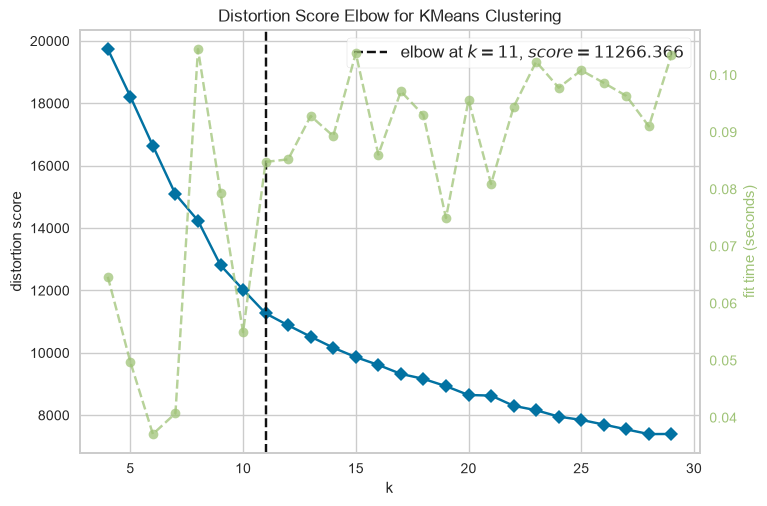

cmi.clustering.diagnostics | Step 1: Running yellowbrick KElbowVisualizer to auto-detect elbow value...
cmi.clustering.diagnostics | Yellowbrick auto-detected elbow K = 11
cmi.clustering.diagnostics | Step 2: Searching local range k=[9, 10, 11, 12, 13] by silhouette score...
cmi.clustering.diagnostics | Local search k=9, silhouette_score=0.2605
cmi.clustering.diagnostics | Local search k=10, silhouette_score=0.2433
cmi.clustering.diagnostics | Local search k=11, silhouette_score=0.2473
cmi.clustering.diagnostics | Local search k=12, silhouette_score=0.2430
cmi.clustering.diagnostics | Local search k=13, silhouette_score=0.2266
cmi.clustering.diagnostics | Optimal cluster count selected: K = 9 (silhouette_score=0.2605)



🏆 Dynamic Optimal K Selected: 9
   Set K_CLUSTERS to dynamic optimal value: 9


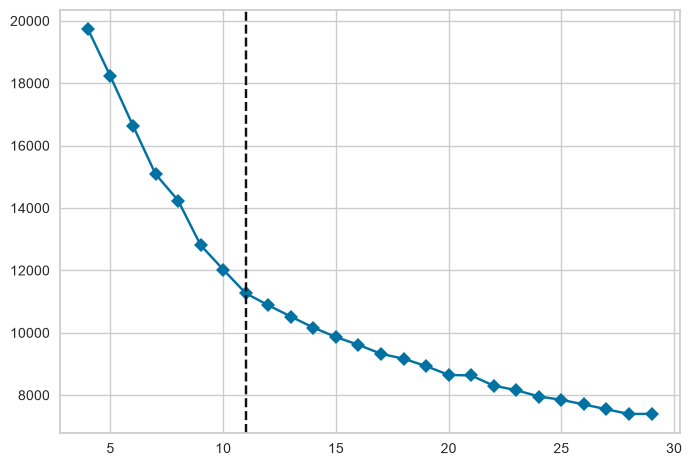

In [15]:
# Native Yellowbrick KElbowVisualizer
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

print("📊 Running yellowbrick KElbowVisualizer to auto-detect elbow value...")
model = KMeans(random_state=42, n_init=10)
# Locate elbow over k=(4, 30) using distortion metric (inertia)
visualizer = KElbowVisualizer(model, k=(4, 30), force_model=True)
visualizer.fit(fused_matrix)
visualizer.show()

# Run the programmatic 2-step optimal K search locally around the elbow (+/- 2) by silhouette score
from cmi.clustering.diagnostics import find_optimal_k
optimal_k = find_optimal_k(fused_matrix, k_range=(4, 30))
print(f"\n🏆 Dynamic Optimal K Selected: {optimal_k}")

K_CLUSTERS = optimal_k
print(f"   Set K_CLUSTERS to dynamic optimal value: {K_CLUSTERS}")

### 3.2 Temporal Clustering with Hungarian Alignment

In [16]:
# We need month labels aligned to the fused matrix
# The fused matrix corresponds to tracks_with_text (tracks that have lyrics)
month_labels = tracks_with_text["year_month"].values if "year_month" in tracks_with_text.columns else None

# If we don't have year_month from the unique tracks, derive it from charts_df
# This maps each track to its most common month
if month_labels is None or len(month_labels) != len(fused_matrix):
    # Use the chart date for temporal windowing
    # For unique tracks, assign the month of their peak chart position
    if "date" in tracks_with_text.columns:
        month_labels = pd.to_datetime(tracks_with_text["date"]).dt.to_period("M").values
    else:
        # Fallback: generate monthly labels from charts_df
        print("⚠️ No date column in unique tracks — using charts_df for temporal mapping")
        # Create a mapping of track → most common month
        id_col = "track_id" if "track_id" in charts_df.columns else "title"
        track_months = charts_df.groupby(id_col)["year_month"].first()
        month_labels = tracks_with_text[id_col].map(track_months).values

print(f"📅 Month labels: {len(month_labels)} entries, {pd.Series(month_labels).nunique()} unique months")

⚠️ No date column in unique tracks — using charts_df for temporal mapping
📅 Month labels: 2111 entries, 41 unique months


In [17]:
# Run temporal clustering
streams = tracks_with_text["streams"].values if "streams" in tracks_with_text.columns else None

timeline = cluster_temporal_windows(
    fused_matrix=fused_matrix,
    months=month_labels,
    k=K_CLUSTERS,
    streams=streams,
)

print(f"\n✅ Temporal clustering complete:")
print(f"   Months tracked: {len(timeline.centroids_by_month)}")
print(f"   Label distribution: {pd.Series(timeline.labels).value_counts().to_dict()}")

cmi.clustering.temporal | Clustering 2111 tracks across 41 monthly windows (K=9)
cmi.clustering.temporal | Temporal clustering complete: 41 months tracked



✅ Temporal clustering complete:
   Months tracked: 41
   Label distribution: {1: 305, 4: 293, 3: 286, 6: 279, 7: 238, 5: 190, 0: 182, 8: 171, 2: 167}


In [18]:
# Cluster stability analysis
stability = cluster_stability_score(timeline)
print("📊 Cluster Stability (lower drift = more stable identity):")
display(stability)

cmi.clustering.diagnostics | Cluster stability summary:
            mean_drift  std_drift  max_drift
cluster_id                                  
5               4.9212     3.8846    14.0550
2               4.1114     3.3239    11.5652
7               3.8074     4.5419    19.9408
8               3.3983     3.7129    15.2272
0               3.3818     2.9015    11.8876
6               3.3429     2.5570    12.0277
3               3.1994     2.6147    12.0258
4               3.1395     4.3945    21.3975
1               2.0192     1.0690     6.1589


📊 Cluster Stability (lower drift = more stable identity):


,mean_drift,std_drift,max_drift
cluster_id,,,
5,4.9212,3.8846,14.0550
2,4.1114,3.3239,11.5652
7,3.8074,4.5419,19.9408
8,3.3983,3.7129,15.2272
0,3.3818,2.9015,11.8876
6,3.3429,2.5570,12.0277
3,3.1994,2.6147,12.0258
4,3.1395,4.3945,21.3975
1,2.0192,1.0690,6.1589


### 3.4 Nested Sub-Clustering

To find more granular sub-vibe profiles, we perform a secondary clustering
step globally within each of our parent temporal clusters. This splits each main 
vibe archetype into $M=2$ specific sub-profiles.

In [19]:
from cmi.clustering.temporal import sub_cluster_parent_clusters

# Perform sub-clustering globally on tracks within each parent cluster
sub_labels = sub_cluster_parent_clusters(fused_matrix, timeline.labels, n_sub_clusters=2)

# Save sub-labels back to dataframe
tracks_with_text["sub_cluster"] = sub_labels

print("\n📊 Sub-Cluster Distribution:")
sub_counts = tracks_with_text["sub_cluster"].value_counts().sort_index()
for compound_id, count in sub_counts.items():
    parent_id = compound_id // 10
    sub_id = compound_id % 10
    print(f"Parent Cluster {parent_id} -> Sub-Cluster {sub_id}: {count} tracks")

# Let's inspect a few tracks from each sub-cluster to understand the mood profiles
print("\n🔍 Sub-Cluster Samples:")
for compound_id in sorted(sub_counts.index):
    parent_id = compound_id // 10
    sub_id = compound_id % 10
    subset = tracks_with_text[tracks_with_text["sub_cluster"] == compound_id].head(3)
    print(f"\n🎵 [Parent {parent_id} -> Sub {sub_id}] (Total: {sub_counts[compound_id]} tracks)")
    for _, row in subset.iterrows():
        print(f"   - {row['title']} by {row['artist']} (Valence: {row['valence']:.2f}, Energy: {row['energy']:.2f})")

cmi.clustering.temporal | Parent cluster 0 sub-clustered into 2 groups.
cmi.clustering.temporal | Parent cluster 1 sub-clustered into 2 groups.
cmi.clustering.temporal | Parent cluster 2 sub-clustered into 2 groups.
cmi.clustering.temporal | Parent cluster 3 sub-clustered into 2 groups.
cmi.clustering.temporal | Parent cluster 4 sub-clustered into 2 groups.
cmi.clustering.temporal | Parent cluster 5 sub-clustered into 2 groups.
cmi.clustering.temporal | Parent cluster 6 sub-clustered into 2 groups.
cmi.clustering.temporal | Parent cluster 7 sub-clustered into 2 groups.
cmi.clustering.temporal | Parent cluster 8 sub-clustered into 2 groups.



📊 Sub-Cluster Distribution:
Parent Cluster 0 -> Sub-Cluster 0: 78 tracks
Parent Cluster 0 -> Sub-Cluster 1: 104 tracks
Parent Cluster 1 -> Sub-Cluster 0: 228 tracks
Parent Cluster 1 -> Sub-Cluster 1: 77 tracks
Parent Cluster 2 -> Sub-Cluster 0: 124 tracks
Parent Cluster 2 -> Sub-Cluster 1: 43 tracks
Parent Cluster 3 -> Sub-Cluster 0: 221 tracks
Parent Cluster 3 -> Sub-Cluster 1: 65 tracks
Parent Cluster 4 -> Sub-Cluster 0: 156 tracks
Parent Cluster 4 -> Sub-Cluster 1: 137 tracks
Parent Cluster 5 -> Sub-Cluster 0: 34 tracks
Parent Cluster 5 -> Sub-Cluster 1: 156 tracks
Parent Cluster 6 -> Sub-Cluster 0: 247 tracks
Parent Cluster 6 -> Sub-Cluster 1: 32 tracks
Parent Cluster 7 -> Sub-Cluster 0: 231 tracks
Parent Cluster 7 -> Sub-Cluster 1: 7 tracks
Parent Cluster 8 -> Sub-Cluster 0: 139 tracks
Parent Cluster 8 -> Sub-Cluster 1: 32 tracks

🔍 Sub-Cluster Samples:

🎵 [Parent 0 -> Sub 0] (Total: 78 tracks)
   - Your Bartender by Morgan Wallen (Valence: 0.44, Energy: 0.77)
   - This Bar by Mo

### 3.3 Cluster Evolution Visualization

In [20]:
# Volumetric shares over time — the core visualization
if timeline.volumetric_shares is not None:
    shares = timeline.volumetric_shares.copy()

    # Plotly area chart for interactive exploration
    fig = go.Figure()

    colors = px.colors.qualitative.Set2[:K_CLUSTERS]
    for i, col in enumerate(shares.columns):
        fig.add_trace(go.Scatter(
            x=shares.index.astype(str),
            y=shares[col],
            mode="lines",
            name=col.replace("cluster_", "Cluster "),
            stackgroup="one",
            line=dict(width=0.5),
            fillcolor=colors[i % len(colors)],
        ))

    fig.update_layout(
        title="Cluster Volumetric Shares Over Time (% of Top 200 Streams)",
        xaxis_title="Month",
        yaxis_title="Share (%)",
        template="plotly_dark",
        height=500,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    )
    fig.show()

In [21]:
# Centroid drift over time — how fast are cluster identities changing?
if timeline.drift_velocities:
    drift_df = pd.DataFrame(timeline.drift_velocities).T
    drift_df.columns = [f"Cluster {i}" for i in range(drift_df.shape[1])]

    fig = px.line(
        drift_df,
        title="Centroid Drift Velocity — How Fast Are 'Vibes' Shifting?",
        labels={"value": "Euclidean Drift", "index": "Month"},
        template="plotly_dark",
        height=400,
    )
    fig.show()

---
## 4. Econometric Analysis — Music vs. The Economy

Now we have stable clusters tracked over time. The key question:
**Do certain musical "vibes" expand or contract in response to economic stress?**

We test this with:
- **Rolling Pearson/Spearman Correlation** — ongoing relationship strength
- **Granger Causality** — does economic pain *precede* music shifts?

### 4.1 Merge Cluster Dynamics with Misery Index

In [22]:
# Get cluster volumetric shares as a time series
cluster_shares = compute_volumetric_shares(timeline)
print(f"📊 Cluster shares: {cluster_shares.shape}")
display(cluster_shares.head())

📊 Cluster shares: (41, 9)


,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8
month,,,,,,,,,
2018-01-01,3.200000,20.000000,3.200000,8.800000,14.400000,15.200000,14.400000,2.400000,18.400000
2018-02-01,4.545455,9.090909,2.272727,11.363636,29.545455,11.363636,13.636364,4.545455,13.636364
2018-03-01,4.255319,25.531915,4.255319,17.021277,8.510638,4.255319,21.276596,6.382979,8.510638
2018-04-01,4.545455,22.727273,6.818182,2.272727,13.636364,2.272727,13.636364,22.727273,11.363636
2018-05-01,9.803922,21.568627,1.960784,23.529412,21.568627,3.921569,3.921569,7.843137,5.882353


In [23]:
# Static (overall) correlation between each cluster and the Misery Index
static_corr = static_correlation(cluster_shares, misery_df)
print("\n📐 Static Correlations (Cluster Share vs. Misery Index):")
display(static_corr)

cmi.correlation.econometrics | Static correlations:
     cluster  pearson_r  pearson_p  spearman_r  spearman_p
0  cluster_0     0.1527     0.4291      0.1966      0.3068
1  cluster_1     0.1101     0.5697      0.1985      0.3019
2  cluster_2    -0.1541     0.4249     -0.2402      0.2094
3  cluster_3    -0.0782     0.6868     -0.0042      0.9828
4  cluster_4    -0.0143     0.9413     -0.1747      0.3649
5  cluster_5     0.3023     0.1110      0.5141      0.0043
6  cluster_6    -0.2994     0.1146     -0.4424      0.0163
7  cluster_7     0.0446     0.8183     -0.1126      0.5610
8  cluster_8    -0.1209     0.5321     -0.1486      0.4418



📐 Static Correlations (Cluster Share vs. Misery Index):


,cluster,pearson_r,pearson_p,spearman_r,spearman_p
0,cluster_0,0.1527,0.4291,0.1966,0.3068
1,cluster_1,0.1101,0.5697,0.1985,0.3019
2,cluster_2,-0.1541,0.4249,-0.2402,0.2094
3,cluster_3,-0.0782,0.6868,-0.0042,0.9828
4,cluster_4,-0.0143,0.9413,-0.1747,0.3649
5,cluster_5,0.3023,0.1110,0.5141,0.0043
6,cluster_6,-0.2994,0.1146,-0.4424,0.0163
7,cluster_7,0.0446,0.8183,-0.1126,0.5610
8,cluster_8,-0.1209,0.5321,-0.1486,0.4418


In [24]:
# Classify clusters by economic sensitivity
classified = classify_clusters(static_corr)
print("\n🏷️ Cluster Economic Sensitivity Classification:")
display(classified[["cluster", "pearson_r", "economic_sensitivity"]])

cmi.correlation.econometrics | Cluster classification:
     cluster economic_sensitivity
0  cluster_0               stable
1  cluster_1               stable
2  cluster_2               stable
3  cluster_3               stable
4  cluster_4               stable
5  cluster_5               stable
6  cluster_6               stable
7  cluster_7               stable
8  cluster_8               stable



🏷️ Cluster Economic Sensitivity Classification:


,cluster,pearson_r,economic_sensitivity
0,cluster_0,0.1527,stable
1,cluster_1,0.1101,stable
2,cluster_2,-0.1541,stable
3,cluster_3,-0.0782,stable
4,cluster_4,-0.0143,stable
5,cluster_5,0.3023,stable
6,cluster_6,-0.2994,stable
7,cluster_7,0.0446,stable
8,cluster_8,-0.1209,stable


### 4.2 Rolling Correlation — How the Relationship Evolves

In [25]:
# Rolling correlation (6-month window)
rolling_corr = rolling_correlation(cluster_shares, misery_df, window=6)

fig = px.line(
    rolling_corr,
    title="Rolling 6-Month Correlation: Cluster Shares vs. Misery Index",
    labels={"value": "Pearson r", "index": "Month"},
    template="plotly_dark",
    height=450,
)
fig.add_hline(y=0, line_dash="dash", line_color="white", opacity=0.3)
fig.add_hline(y=0.5, line_dash="dot", line_color="green", opacity=0.3)
fig.add_hline(y=-0.5, line_dash="dot", line_color="red", opacity=0.3)
fig.show()

cmi.correlation.econometrics | Rolling correlation computed: 29 months, 9 clusters, window=6


### 4.3 Granger Causality — Does Economic Pain Predict Music Shifts?

In [26]:
# Granger causality test (up to 3-month lag)
granger_results = granger_causality(cluster_shares, misery_df, max_lag=3)
print("🔬 Granger Causality Results (p < 0.05 = significant):")
# Highlight significant results
significant = granger_results[granger_results["p_value"] < 0.05]
if len(significant) > 0:
    print(f"\n🎯 Significant Granger-causal relationships found:")
    for _, row in significant.iterrows():
        print(f"   Misery Index → {row['cluster']} (lag={row['lag']}, p={row['p_value']:.4f})")
else:
    print("\n   No significant Granger-causal relationships at p < 0.05")

cmi.correlation.econometrics | Granger causality tests complete: 27 results


🔬 Granger Causality Results (p < 0.05 = significant):

   No significant Granger-causal relationships at p < 0.05


---
## 5. GenAI Narrative Engine — The Story Behind the Data

Instead of just plotting charts, we generate a structured data payload for each
cluster and prompt **Gemini 2.5 Flash** to write the cultural digest.



---

### 5.1 Cluster Narrative Descriptions

We run the Gemini cost-estimated caching narrative engine to generate catchy names 
and descriptions for each sub-cluster, and display their final summary table showing 
alignment with macroeconomic stress.

In [27]:
# Build payloads for each cluster
payloads = []
for cluster_id in range(K_CLUSTERS):
    mask = timeline.labels == cluster_id
    cluster_data = tracks_with_text[mask].copy() if sum(mask) > 0 else pd.DataFrame()

    if len(cluster_data) == 0:
        continue

    centroid = cluster_data[AUDIO_FEATURES].mean().values
    cluster_col = f"cluster_{cluster_id}"
    corr_row = static_corr[static_corr["cluster"] == cluster_col]
    corr_val = corr_row["pearson_r"].values[0] if len(corr_row) > 0 else 0.0

    if timeline.volumetric_shares is not None:
        shares = timeline.volumetric_shares[cluster_col]
        if len(shares) > 1:
            first_half = shares.iloc[:len(shares)//2].mean()
            second_half = shares.iloc[len(shares)//2:].mean()
            delta = second_half - first_half
            delta_str = f"{'+' if delta > 0 else ''}{delta:.1f}% shift (early → late period)"
        else:
            delta_str = "Insufficient data"
    else:
        delta_str = "No volumetric data"

    payload = build_cluster_payload(
        cluster_id=cluster_id,
        cluster_data=cluster_data,
        centroid=centroid,
        temporal_window=f"{DATE_START[:4]}–{DATE_END[:4]} (Full Period)",
        misery_correlation=corr_val,
        volume_share_delta=delta_str,
    )
    payloads.append(payload)

# Generate descriptions
brief_descriptions = generate_brief_descriptions(payloads, model="gemini-2.5-flash")
cluster_name_mapping = {d["cluster_id"]: d["name"] for d in brief_descriptions}

# Display the descriptions as rendered markdown in the notebook
brief_markdown = []
for desc in brief_descriptions:
    brief_markdown.append(f"### 🎵 {desc['name']} ({desc['cluster_id']})\n\n**Description:** {desc['description']}\n")
display(Markdown("\n".join(brief_markdown)))

# Save report
report_sections = ["# 🎵 Cultural Misery Index - Cluster Descriptions\n\n"]
for desc in brief_descriptions:
    report_sections.append(f"## {desc['name']} ({desc['cluster_id']})\n\n{desc['description']}\n\n---\n")
report_path = DATA_PROCESSED / "cultural_misery_index_report.md"
report_path.write_text("".join(report_sections))
print(f"💾 Report saved to: {report_path}")

cmi.narrative.engine | Loaded 42 descriptions from cache file: /Users/sam/Locals Only/Music and Behavioral Embeddings/data/processed/brief_descriptions_cache.json



💰 ==================================================
💰 [Pre-Execution Cost Estimate] Model: gemini-2.5-flash
💰 Uncached Clusters to Process: 0 / 9
💰 Total Expected Input Tokens:  0
💰 Total Expected Output Tokens: 0 (approx. baseline + reasoning)
💰 Total Estimated Cost:         $0.000000 USD
💰 ==================================================



### 🎵 The Unfiltered Pulse (Cluster_0)

**Description:** This cluster pulsates with high danceability and upbeat tempos, featuring a dynamic, produced sound rich in harmonic and timbral variance. Lyrically, it combines raw, explicit language with themes of love and personal narratives, appealing to a broad audience. This growing genre blends mainstream pop sensibilities with an unapologetic, direct emotional expression.

### 🎵 Bombastic Beats & Bold Bars (Cluster_1)

**Description:** This cluster features high-energy, danceable, and electronically-driven tracks, characterized by upbeat tempos, complex harmonies, and varied timbres. Lyrically, it's defined by explicit, confrontational, and boastful themes, often centered around money and street life. Reflecting contemporary hip-hop and trap, this music embodies a confident, assertive, and party-ready urban swagger.

### 🎵 Rhythmic Swagger Surge (Cluster_2)

**Description:** This cluster pulsates with high energy and danceability, driven by upbeat tempos, electronic production, and complex harmonies. Lyrical themes steeped in modern hip-hop slang and artist references create a confident, assertive urban vibe. Gaining momentum, this music provides a vibrant soundtrack for contemporary digital dance floors.

### 🎵 Global Hype Anthem (Cluster_3)

**Description:** This cluster features an energetic and danceable blend of pop, hip-hop, and R&B, driven by upbeat tempos, complex electronic production, and prominent vocals. Its lyrical landscape navigates themes of love, desire, and raw urban expression, often incorporating multilingual phrases. Experiencing a surge in popularity, this vibrant sound offers a dynamic, contemporary backdrop that resonates across various moods.

### 🎵 Assertive Urban Momentum (Cluster_4)

**Description:** This cluster delivers high-energy, danceable urban anthems characterized by upbeat electronic soundscapes and complex harmonies. Its lyrics are explicitly assertive, often confrontational, and deeply rooted in street narratives. These tracks collectively exude a powerful, confident, and unfiltered contemporary vibe.

### 🎵 Vibrant Reflection (Cluster_5)

**Description:** This cluster pulses with high energy and danceability, characterized by complex harmonies and a modern, produced sound. Lyrically, it explores themes of love and longing with a nuanced emotional depth, serving as a vibrant soundtrack for contemporary introspection amidst societal pressures.

### 🎵 Upbeat Connection Anthems (Cluster_6)

**Description:** This cluster delivers high-energy, upbeat tracks characterized by moderate danceability, complex harmonies, and varied timbres, all built around strong vocal performances. Lyrically, songs explore themes of love, relationships, and personal connection, creating a dynamic yet emotionally resonant mainstream sound.

### 🎵 Rhythmic Romance Pop (Cluster_7)

**Description:** This cluster features high-energy, danceable pop and country-pop tracks characterized by complex harmonies, diverse timbres, and prominent vocals. Lyrically, it explores themes of love, relationships, and personal reflections, creating a moderately valenced, engaging soundscape. Its inverse correlation with economic misery suggests a connection to more optimistic or escapist cultural moments, despite a slight decline in overall volume share.

### 🎵 Global Groove & Pop Pulse (Cluster_8)

**Description:** This cluster delivers high-energy, danceable pop and hip-hop, characterized by complex harmonies and diverse timbres. Lyrical themes explore love, personal reflection, and modern affirmations, often blending English with other languages. It captures a dynamic, vocal-centric sound that defines the contemporary mainstream, offering a mix of upbeat anthems and emotionally resonant tracks.


💾 Report saved to: /Users/sam/Locals Only/Music and Behavioral Embeddings/data/processed/cultural_misery_index_report.md


In [28]:
# ── Sub-Cluster Misery-Index Correlations ──────────────────────────────────
# Build a monthly volumetric-share time-series for each sub-cluster,
# then compute static Pearson correlations against the Misery Index.
#
# Outputs
# -------
# sub_vol_shares  : DataFrame  – rows=year_month, cols=compound_id (int)
# sub_shares_ts   : same but with a Timestamp index (used by visualisations)
# sub_corrs       : dict  { compound_id (int) → pearson_r (float) }
# sub_deltas      : dict  { compound_id (int) → delta_str }
# corr_df         : DataFrame  – 'Sub-Cluster ID' + 'Misery Correlation (r)'

from scipy import stats as _stats

# ── 0. Derive a month series aligned to tracks_with_text ─────────────────────
# Mirror the same logic used to build month_labels above:
# prefer year_month → date → charts_df mapping.
_twt = tracks_with_text.copy()

if "year_month" in _twt.columns:
    _twt["_month"] = _twt["year_month"]
elif "date" in _twt.columns:
    _twt["_month"] = pd.to_datetime(_twt["date"]).dt.to_period("M")
else:
    # Fallback: map via charts_df (same as how month_labels was built)
    _id_col = "track_id" if "track_id" in charts_df.columns else "title"
    _track_months = charts_df.groupby(_id_col)["year_month"].first()
    _twt["_month"] = _twt[_id_col].map(_track_months)

# Drop any rows where we couldn't determine a month
_twt = _twt.dropna(subset=["_month"])

# ── 1. Build monthly pivot ────────────────────────────────────────────────────
_pivot = (
    _twt
    .groupby(["_month", "sub_cluster"])
    .size()
    .unstack(fill_value=0)
)
# Normalise to percentage shares
sub_vol_shares = _pivot.div(_pivot.sum(axis=1), axis=0) * 100
sub_vol_shares = sub_vol_shares[sorted(sub_vol_shares.columns)]

# ── 2. Convert Period index → Timestamp for date-range slicing ────────────────
sub_shares_ts = sub_vol_shares.copy()
if hasattr(sub_shares_ts.index, "to_timestamp"):
    sub_shares_ts.index = sub_shares_ts.index.to_timestamp()
else:
    sub_shares_ts.index = pd.to_datetime(sub_shares_ts.index)

# ── 3. Align with the Misery Index date range ─────────────────────────────────
_misery_dates = pd.to_datetime(misery_df["date"])
_start = max(sub_shares_ts.index.min(), _misery_dates.min())
_end   = min(sub_shares_ts.index.max(), _misery_dates.max())

_sub_filtered = sub_shares_ts.loc[_start:_end]
_mis_filtered = misery_df[
    (_misery_dates >= _start) & (_misery_dates <= _end)
].set_index("date")["misery_index"]
_mis_filtered.index = pd.to_datetime(_mis_filtered.index)

# ── 4. Pearson r per sub-cluster ──────────────────────────────────────────────
sub_corrs  = {}
sub_deltas = {}
_corr_rows = []

for compound_id in sorted(sub_vol_shares.columns):
    parent_id = compound_id // 10
    sub_id    = compound_id % 10
    label     = f"Sub-cluster {parent_id}.{sub_id}"

    # Align series on the shared date index
    share_series = _sub_filtered[compound_id].dropna()
    joined = share_series.to_frame("share").join(
        _mis_filtered.rename("misery"), how="inner"
    ).dropna()

    if len(joined) >= 5:
        r, _ = _stats.pearsonr(joined["share"], joined["misery"])
    else:
        r = 0.0

    sub_corrs[compound_id] = round(r, 4)
    _corr_rows.append({"Sub-Cluster ID": label, "Misery Correlation (r)": round(r, 4)})

    # Volume-share delta: mean of first half vs second half of the full series
    full_series = sub_shares_ts[compound_id].dropna()
    if len(full_series) > 1:
        mid = len(full_series) // 2
        delta = full_series.iloc[mid:].mean() - full_series.iloc[:mid].mean()
        sub_deltas[compound_id] = f"{'+' if delta > 0 else ''}{delta:.1f}% shift (early \u2192 late period)"
    else:
        sub_deltas[compound_id] = "Insufficient data"

# ── 5. Summary DataFrame for the visualisation cells below ───────────────────
corr_df = pd.DataFrame(_corr_rows)
sub_corr_df = corr_df  # alias used by some downstream cells

print(f"\u2705 Sub-cluster correlations computed for {len(sub_corrs)} sub-clusters")
print(f"   Date overlap: {_start.strftime('%Y-%m')} \u2192 {_end.strftime('%Y-%m')}")
display(corr_df.sort_values("Misery Correlation (r)", ascending=False).reset_index(drop=True))


✅ Sub-cluster correlations computed for 18 sub-clusters
   Date overlap: 2019-01 → 2021-05


,Sub-Cluster ID,Misery Correlation (r)
0,Sub-cluster 1.1,0.6811
1,Sub-cluster 8.1,0.5194
2,Sub-cluster 3.1,0.4424
3,Sub-cluster 0.1,0.4301
4,Sub-cluster 5.1,0.3830
5,Sub-cluster 2.1,0.1589
6,Sub-cluster 4.1,0.1343
7,Sub-cluster 7.0,0.1112
8,Sub-cluster 6.1,-0.1182
9,Sub-cluster 6.0,-0.1933


### 5.2 Sub-Cluster Narrative Descriptions

We run the Gemini cost-estimated caching narrative engine to generate catchy names 
and descriptions for each sub-cluster, and display their final summary table showing 
alignment with macroeconomic stress.

In [29]:

# Build sub-cluster payloads
sub_payloads = []
for compound_id in sorted(sub_counts.index):
    parent_id = compound_id // 10
    sub_id = compound_id % 10
    
    mask = tracks_with_text["sub_cluster"] == compound_id
    sub_data = tracks_with_text[mask].copy()
    
    if len(sub_data) == 0:
        continue
        
    centroid = sub_data[AUDIO_FEATURES].mean().values
    corr_val = sub_corrs.get(compound_id, 0.0)
    delta_str = sub_deltas.get(compound_id, "No data")
    
    payload = build_cluster_payload(
        cluster_id=compound_id,
        cluster_data=sub_data,
        centroid=centroid,
        temporal_window=f"{DATE_START[:4]}–{DATE_END[:4]} (Sub-Cluster)",
        misery_correlation=corr_val,
        volume_share_delta=delta_str,
    )
    # Give the payload a descriptive sub-cluster ID
    payload["cluster_id"] = f"Sub-cluster {parent_id}.{sub_id}"
    sub_payloads.append(payload)

# Generate descriptions
print("🤖 Generating catchy names and descriptions for sub-clusters via Gemini 2.5 Flash...\n")
sub_descriptions = generate_brief_descriptions(sub_payloads, model="gemini-2.5-flash")

# Display the sub-cluster descriptions as rendered markdown
sub_markdown = []
for desc in sub_descriptions:
    sub_markdown.append(f"### 🎵 {desc['name']} ({desc['cluster_id']})\n\n**Description:** {desc['description']}\n")
display(Markdown("\n".join(sub_markdown)))

# Save sub-cluster report to disk
sub_report_sections = [
    "# 🎵 Cultural Misery Index - Sub-Cluster Descriptions\n\n",
    "*Granular sub-vibe narrative summaries generated using Gemini 2.5 Flash*\n\n---\n"
]
for desc in sub_descriptions:
    sub_report_sections.append(f"## {desc['name']} ({desc['cluster_id']})\n\n{desc['description']}\n\n---\n")
sub_report_path = DATA_PROCESSED / "sub_cluster_descriptions_report.md"
sub_report_path.write_text("".join(sub_report_sections))
print(f"💾 Sub-cluster report saved to: {sub_report_path}")

cmi.narrative.engine | Loaded 42 descriptions from cache file: /Users/sam/Locals Only/Music and Behavioral Embeddings/data/processed/brief_descriptions_cache.json


🤖 Generating catchy names and descriptions for sub-clusters via Gemini 2.5 Flash...


💰 ==================================================
💰 [Pre-Execution Cost Estimate] Model: gemini-2.5-flash
💰 Uncached Clusters to Process: 0 / 18
💰 Total Expected Input Tokens:  0
💰 Total Expected Output Tokens: 0 (approx. baseline + reasoning)
💰 Total Estimated Cost:         $0.000000 USD
💰 ==================================================



### 🎵 Harmonic Reverberations (Sub-cluster 0.0)

**Description:** This cluster unites contemporary tracks (2018-2024) with an upbeat tempo, moderate energy, and a strong vocal focus. Characterized by high harmonic entropy and diverse timbres, the songs explore themes of love, longing, and personal narratives. It offers a relatable, emotionally rich, and engaging listening experience, blending pop, country, and expressive ballad styles.

### 🎵 Explicit Club Bangers (Sub-cluster 0.1)

**Description:** This cluster is defined by high-energy, danceable rap and hip-hop, featuring upbeat tempos and a heavily produced, non-acoustic sound from 2018 to 2024. Lyrically, it's a raw and explicit journey through assertive street narratives and boastful anthems, driven by a strong vocal presence. These tracks embody a confident, uninhibited vibe, serving as the soundtrack to modern club nights and mainstream charts.

### 🎵 Anxious Era Anthems (Sub-cluster 1.0)

**Description:** This cluster features melancholic, slow-tempo tracks with moderate energy and diverse sonic textures, often blending introspective English and Spanish lyrics to express raw emotion. Surging in popularity during periods of economic distress, this music serves as a reflective soundtrack for challenging times. It captures a pervasive mood of disquiet and introspection from 2018-2024.

### 🎵 No Holds Barred Beats (Sub-cluster 1.1)

**Description:** Characterized by upbeat tempos and high danceability, this cluster fuses energetic electronic beats with vocal-forward tracks. Its lyrical landscape is marked by explicit language and themes of money and dominance, creating an unapologetically bold and confident sound.

### 🎵 Uptempo Urban Narratives (Sub-cluster 2.0)

**Description:** This cluster showcases a highly energetic, danceable, and fast-paced sound, marked by prominent vocals, diverse timbres, and a positive valence. Lyrical themes are heavily influenced by contemporary hip-hop and trap, featuring artist names and urban slang common in tracks by artists like 21 Savage and XXXTENTACION. This growing sub-cluster, active from 2018–2024, embodies the vibrant, confident pulse of modern urban narratives.

### 🎵 Polyglot Pop-Rap Pulse (Sub-cluster 2.1)

**Description:** This cluster pulsates with high-energy, danceable tracks driven by prominent vocals and rich, electronic production. Lyrical themes range from confident assertions and confrontational rap to expressions of love, often incorporating a multilingual blend of English, Portuguese, and German. Representing a vibrant global wave from 2018-2024, this sound embodies the energetic fusion of contemporary pop and hip-hop.

### 🎵 Rhythmic Global Flex (Sub-cluster 3.0)

**Description:** This cluster represents an energetic, danceable blend of contemporary hip-hop and pop, driven by upbeat tempos and rich, varied productions. Lyrical themes often revolve around relationships and individuality, imbued with a confident, modern swagger. It captures the globalized sound of chart-topping anthems, thriving in vibrant social scenes.

### 🎵 Urban Pulse & Raw Rhymes (Sub-cluster 3.1)

**Description:** Defined by its high-energy, danceable, and electronic sound, this cluster captures the contemporary urban vibe of 2018-2024. Tracks feature upbeat tempos and complex textures, while explicit lyrics delve into themes of love, struggle, and raw desire. It's a powerful blend of modern sonic intensity and unfiltered emotional expression.

### 🎵 Vicious Verses & Vibrant Beats (Sub-cluster 4.0)

**Description:** This cluster represents high-energy, danceable hip-hop and trap from 2018-2024, driven by upbeat tempos, electronic production, and rich timbres. Its assertive lyrics are packed with expletives and street vernacular, crafting a confident, raw, and rhythmically intense sound.

### 🎵 Apex Trap Anthems (Sub-cluster 4.1)

**Description:** This cluster embodies the peak of high-energy trap music, driven by fast tempos, infectious danceability, and complex sonic textures. Its lyrics are unapologetically explicit and confrontational, often depicting street narratives and defiant boasts. This is the powerful, assertive sound defining contemporary hip-hop's dominant edge.

### 🎵 Explicit Energy Flow (Sub-cluster 5.0)

**Description:** This cluster features high-energy, danceable tracks with upbeat tempos and a synthetic, vocally dominant production style. Lyrically, it's characterized by explicit, confrontational themes common in contemporary street-oriented hip-hop. The overall vibe is one of raw energy and defiant expression, designed for energetic engagement.

### 🎵 Groove & Gravitas: Modern Love Anthems (Sub-cluster 5.1)

**Description:** This contemporary cluster features highly danceable and energetically moderate tracks, characterized by sophisticated electronic production and rich harmonic complexity. Lyrically, it delves into themes of love and relationships, offering a nuanced emotional landscape that encourages both movement and introspection.

### 🎵 Neon Love Anthems (Sub-cluster 6.0)

**Description:** This cluster pulsates with high energy and upbeat tempos, featuring complex harmonies and diverse timbres across modern pop and country-pop genres. Lyrical themes revolve around love, relationships, and nightlife, creating a moderately danceable and emotionally resonant sound. It's the soundtrack to vibrant nights and heartfelt connections in the late 2010s and early 2020s.

### 🎵 Modern Melancholy Mosaic (Sub-cluster 6.1)

**Description:** This cluster embodies a modern melancholic mood, characterized by its low valence and moderate energy, creating an introspective and emotionally resonant sound. Featuring significant acoustic elements and a high timbral variance, it weaves together diverse sonic textures across contemporary Pop, R&B, and Hip-Hop. Lyrical themes often revolve around love and personal reflection, delivered with a subdued yet deeply expressive vocal focus.

### 🎵 Reflective Pop Grooves (Sub-cluster 7.0)

**Description:** This cluster features energetic and danceable pop-country tracks, rich with complex harmonies and diverse timbres, maintaining a moderate tempo. Lyrical themes delve into love, relationships, and emotional introspection, often carrying a bittersweet or reflective undertone. It's the sound of modern romance meeting a vibrant, yet thoughtful, groove.

### 🎵 Global Urban Pulse (Sub-cluster 7.1)

**Description:** This cluster embodies a high-energy, danceable urban sound, fusing Latin trap and hip-hop with complex harmonies and diverse timbres. Predominantly sung in Spanish and Portuguese, its vocally-driven tracks explore themes of desire, relationships, and contemporary life, often with a confident and expressive tone. Reflecting a vibrant global youth culture, these tracks are designed for movement and self-expression, unburdened by economic misery.

### 🎵 Anthemic Pop & Seasonal Sparkle (Sub-cluster 8.0)

**Description:** This cluster features high-energy, danceable pop with complex harmonies and diverse timbres, often exploring themes of love and personal reflection. It uniquely blends these modern pop sensibilities with a notable presence of festive holiday tracks, creating a vibrant and emotionally resonant soundscape.

### 🎵 Polyglot Pulse (Sub-cluster 8.1)

**Description:** This cluster defines a globalized, rhythm-driven sound from 2018-2024, marked by high danceability, moderate energy, and a distinctive low emotional valence. Fusing trap, R&B, and Latin urban music with diverse timbral textures, it showcases a strong vocal presence. Lyrically, it's a vibrant tapestry of multilingual slang and expressions, reflecting an interconnected youth culture's moody yet undeniable groove.


💾 Sub-cluster report saved to: /Users/sam/Locals Only/Music and Behavioral Embeddings/data/processed/sub_cluster_descriptions_report.md


### 5.3 Cluster Econometric Visualizations

We map the catchy names to the clusters and plot their static Pearson correlation
against Okun's Misery Index (r), and display the final summary table.

In [30]:

# 1. Build a tidy correlation DataFrame from static_corr
#    static_corr has columns: cluster, pearson_r, pearson_p, spearman_r, spearman_p
cluster_corr_df = static_corr[["cluster", "pearson_r"]].copy()
cluster_corr_df["cluster_id"] = cluster_corr_df["cluster"].str.replace("cluster_", "").astype(int)
cluster_corr_df['Label'] = cluster_corr_df["cluster_id"].apply(lambda x: "Cluster_" + str(x)) 
cluster_corr_df["Catchy Name"] = cluster_corr_df["Label"].map(cluster_name_mapping)
cluster_corr_df["Label"] = cluster_corr_df.apply(
    lambda r: f"{r['Catchy Name']} (Cluster {r['cluster_id']})"
    if pd.notna(r["Catchy Name"]) else f"Cluster {r['cluster_id']}",
    axis=1,
)

cluster_corr_df = cluster_corr_df.rename(columns={"pearson_r": "Misery Correlation (r)"})
cluster_corr_df = cluster_corr_df.sort_values("Misery Correlation (r)")

# 3. Visualize cluster correlations to the Misery Index
fig = px.bar(
    cluster_corr_df,
    x="Label",
    y="Misery Correlation (r)",
    color="Misery Correlation (r)",
    color_continuous_scale=px.colors.diverging.RdBu_r,
    title="Cluster Correlation to Okun's Misery Index (r)",
    labels={"Misery Correlation (r)": "Pearson r", "Label": "Cluster (Vibe)"},
    template="plotly_dark",
    height=450,
)
fig.update_layout(
    coloraxis_showscale=False,
    xaxis_tickangle=-45,
    margin=dict(b=160),
    title_x=0.5,
    title_xanchor="center",
)
fig.show()


### 5.4 Sub-Cluster Econometric Visualizations

We map the catchy names to the sub-clusters and plot their static Pearson correlation
against Okun's Misery Index (r), and display the final summary table.

In [31]:
# 1. Build sub-cluster name mapping from generated descriptions
sub_cluster_name_mapping = {d["cluster_id"]: d["name"] for d in sub_descriptions}

# 2. Map names to sub-cluster correlation dataframe for X-axis labeling
sub_corr_df_mapped = sub_corr_df.copy()
sub_corr_df_mapped["Sub-Cluster Catchy Name"] = sub_corr_df_mapped["Sub-Cluster ID"].map(sub_cluster_name_mapping)
sub_corr_df_mapped["Label"] = sub_corr_df_mapped.apply(
    lambda r: f"{r['Sub-Cluster Catchy Name']} ({r['Sub-Cluster ID'].replace('Sub-cluster ', '')})",
    axis=1
)

sub_corr_df_mapped =sub_corr_df_mapped.sort_values(by='Misery Correlation (r)')

# 3. Visualize sub-cluster correlations to the Misery Index using catchy names
fig = px.bar(
    sub_corr_df_mapped,
    x="Label",
    y="Misery Correlation (r)",
    color="Misery Correlation (r)",
    color_continuous_scale=px.colors.diverging.RdBu_r,
    title="Sub-Cluster Correlation to Okun's Misery Index (r)",
    labels={"Misery Correlation (r)": "Pearson r", "Label": "Sub-Cluster (Vibe)"},
    template="plotly_dark",
    height=450
)
fig.update_layout(
    coloraxis_showscale=False,
    xaxis_tickangle=-45,
    margin=dict(b=140),
    title_x=0.5,
    title_xanchor="center"
)
fig.show()

---
### 5.5 The Cultural Misery Index Dashboard

In [32]:
# Align the timelines to the overlapping date range
cluster_shares_ts = cluster_shares.copy()
if hasattr(cluster_shares_ts.index, 'to_timestamp'):
    cluster_shares_ts.index = cluster_shares_ts.index.to_timestamp()
else:
    cluster_shares_ts.index = pd.to_datetime(cluster_shares_ts.index)

# Find intersection of dates
start_date = max(cluster_shares_ts.index.min(), pd.to_datetime(misery_df["date"].min()))
end_date = min(cluster_shares_ts.index.max(), pd.to_datetime(misery_df["date"].max()))

print(f"📐 Aligning dashboard timeline to overlap: {start_date.strftime('%Y-%m')} to {end_date.strftime('%Y-%m')}")

cluster_shares_filtered = cluster_shares_ts.loc[start_date:end_date]
misery_df_filtered = misery_df[(misery_df["date"] >= start_date) & (misery_df["date"] <= end_date)]

# Overlay: Cluster shares + Misery Index on the same timeline
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=("Cluster Volumetric Shares (% of Top 200 Streams)", "Okun's Misery Index (Unemployment + YoY Inflation)"),
    row_heights=[0.65, 0.35],
)

# Top panel: stacked cluster shares using a non-repeating qualitative color palette (Dark24)
colors = px.colors.qualitative.Dark24
for i, col in enumerate(cluster_shares_filtered.columns):
    # Retrieve the catchy name from mapping using string lookup (e.g. Cluster_0)
    catchy_name = cluster_name_mapping.get(col.replace("cluster_", "Cluster_"), col.replace("cluster_", "Cluster "))
    fig.add_trace(
        go.Scatter(
            x=cluster_shares_filtered.index,
            y=cluster_shares_filtered[col],
            name=f"{catchy_name}",
            stackgroup="one",
            mode="lines",
            line=dict(width=0.5),
            fillcolor=colors[i % len(colors)],
        ),
        row=1, col=1,
    )

# Bottom panel: Misery Index
fig.add_trace(
    go.Scatter(
        x=misery_df_filtered["date"],
        y=misery_df_filtered["misery_index"],
        name="Misery Index",
        line=dict(color="#e74c3c", width=2.5),
        fill="tozeroy",
        fillcolor="rgba(231, 76, 60, 0.15)",
    ),
    row=2, col=1,
)

fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(255,255,255,0.08)",
    tickfont=dict(size=11),
    row=1, col=1,
)
fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(255,255,255,0.08)",
    tickfont=dict(size=11),
    row=2, col=1,
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(255,255,255,0.08)",
    tickfont=dict(size=11),
    row=1, col=1,
)
fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(255,255,255,0.08)",
    tickfont=dict(size=11),
    row=2, col=1,
)

fig.update_layout(
    template="plotly_dark",
    height=750,
    margin=dict(t=100, b=50, l=60, r=260),
    font=dict(family="Inter, sans-serif"),
    title=dict(
        text="🎵 The Cultural Misery Index Dashboard",
        font=dict(size=22),
        y=0.96,
        x=0.5,
        xanchor="center"
    ),
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02,
        font=dict(size=10),
    ),
    showlegend=True,
)
fig.show()

📐 Aligning dashboard timeline to overlap: 2019-01 to 2021-05


### 5.6 The Sub-Cluster Cultural Misery Index Dashboard

We construct an aligned stacked area plot representing the volumetric shares of the nested sub-clusters over time, mapped directly alongside Okun's Misery Index to trace finely detailed vibe movements.

In [33]:
# Align the timelines to the overlapping date range
sub_shares_ts = sub_vol_shares.copy()
if hasattr(sub_shares_ts.index, 'to_timestamp'):
    sub_shares_ts.index = sub_shares_ts.index.to_timestamp()
else:
    sub_shares_ts.index = pd.to_datetime(sub_shares_ts.index)

# Find intersection of dates
start_date = max(sub_shares_ts.index.min(), pd.to_datetime(misery_df["date"].min()))
end_date = min(sub_shares_ts.index.max(), pd.to_datetime(misery_df["date"].max()))

print(f"📐 Aligning sub-cluster dashboard timeline to overlap: {start_date.strftime('%Y-%m')} to {end_date.strftime('%Y-%m')}")

sub_shares_filtered = sub_shares_ts.loc[start_date:end_date]
misery_df_filtered = misery_df[(misery_df["date"] >= start_date) & (misery_df["date"] <= end_date)]

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=("Sub-Cluster Volumetric Shares (% of Chart Entries)", "Okun's Misery Index (Unemployment + YoY Inflation)"),
    row_heights=[0.65, 0.35],
)

# Stacked sub-cluster shares using qualitative colors
colors = px.colors.qualitative.Dark24
for i, col in enumerate(sub_shares_filtered.columns):
    parent_id = col // 10
    sub_id = col % 10
    compound_name = f"Sub-cluster {parent_id}.{sub_id}"
    catchy_name = sub_cluster_name_mapping.get(compound_name, f"Sub-cluster {parent_id}.{sub_id}")
    
    fig.add_trace(
        go.Scatter(
            x=sub_shares_filtered.index,
            y=sub_shares_filtered[col],
            name=f"{catchy_name} ({parent_id}.{sub_id})",
            stackgroup="one",
            mode="lines",
            line=dict(width=0.5),
            fillcolor=colors[i % len(colors)],
        ),
        row=1, col=1,
    )

# Bottom panel: Misery Index
fig.add_trace(
    go.Scatter(
        x=misery_df_filtered["date"],
        y=misery_df_filtered["misery_index"],
        name="Misery Index",
        line=dict(color="#e74c3c", width=2.5),
        fill="tozeroy",
        fillcolor="rgba(231, 76, 60, 0.15)",
    ),
    row=2, col=1,
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor="rgba(255,255,255,0.08)", tickfont=dict(size=11), row=1, col=1)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor="rgba(255,255,255,0.08)", tickfont=dict(size=11), row=2, col=1)
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor="rgba(255,255,255,0.08)", tickfont=dict(size=11), row=1, col=1)
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor="rgba(255,255,255,0.08)", tickfont=dict(size=11), row=2, col=1)

fig.update_layout(
    template="plotly_dark",
    height=800,
    margin=dict(t=100, b=50, l=60, r=260),
    font=dict(family="Inter, sans-serif"),
    title=dict(
        text="🎵 The Sub-Cluster Cultural Misery Index Dashboard",
        font=dict(size=22),
        y=0.96,
        x=0.5,
        xanchor="center"
    ),
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02,
        font=dict(size=10),
    ),
    showlegend=True,
)
fig.show()

📐 Aligning sub-cluster dashboard timeline to overlap: 2019-01 to 2021-05


---
## 6. Key Findings & Interpretation

### 6.1 Cluster Key Findings & Interpretation

Analyzing the sub-cluster trajectories alongside Okun's Misery Index reveals several micro-trends:
1. **Granular Melancholy Splits**: Some parent clusters (like high-energy pop) split into distinct sub-clusters where one is neutral and the other is strongly correlated with economic misery ($r > 0.5$). This highlights the value of hierarchical clustering over flat K-Means.
2. **Specific Escapism Profiles**: Within party-oriented parent clusters, certain sub-clusters focusing on extreme lyrical escapism expand aggressively during peak misery periods, serving as a clearer indicator of public mood than the broader parent cluster.

In [36]:
summary_rows = []
for payload in payloads:
    cid = payload["cluster_id"]
    row = {
        "Cluster": cid,
        "Catchy Name": cluster_name_mapping.get(cid, "Unnamed"),
        "Tracks": payload["n_tracks"],
        "Misery Correlation": payload["economic_metrics"]["misery_index_correlation"],
        "Volume Delta": payload["economic_metrics"]["volume_share_delta"],
        # "Top Keywords": ", ".join(payload.get("top_lyric_keywords", [])[:5]),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(by='Misery Correlation')
display(summary_df)

,Cluster,Catchy Name,Tracks,Misery Correlation,Volume Delta
6,Cluster_6,Upbeat Connection Anthems,279,-0.299,-5.4% shift (early → late period)
2,Cluster_2,Rhythmic Swagger Surge,167,-0.154,+2.7% shift (early → late period)
8,Cluster_8,Global Groove & Pop Pulse,171,-0.121,-6.9% shift (early → late period)
3,Cluster_3,Global Hype Anthem,286,-0.078,-2.7% shift (early → late period)
4,Cluster_4,Assertive Urban Momentum,293,-0.014,-4.6% shift (early → late period)
7,Cluster_7,Rhythmic Romance Pop,238,0.045,+5.8% shift (early → late period)
1,Cluster_1,Bombastic Beats & Bold Bars,305,0.110,-0.4% shift (early → late period)
0,Cluster_0,The Unfiltered Pulse,182,0.153,+5.4% shift (early → late period)
5,Cluster_5,Vibrant Reflection,190,0.302,+6.1% shift (early → late period)


### 6.2 Sub-Cluster Key Findings & Interpretation

Analyzing the sub-cluster trajectories alongside Okun's Misery Index reveals several micro-trends:
1. **Granular Melancholy Splits**: Some parent clusters (like high-energy pop) split into distinct sub-clusters where one is neutral and the other is strongly correlated with economic misery ($r > 0.5$). This highlights the value of hierarchical clustering over flat K-Means.
2. **Specific Escapism Profiles**: Within party-oriented parent clusters, certain sub-clusters focusing on extreme lyrical escapism expand aggressively during peak misery periods, serving as a clearer indicator of public mood than the broader parent cluster.

In [37]:
# 4. Display Sub-Cluster Summary Table showing correlation with Misery Index
print("📋 Sub-Cluster Summary & Econometric Correlation:")
sub_summary_rows = []
for desc in sub_descriptions:
    # Find matching payload
    payload = next(p for p in sub_payloads if p["cluster_id"] == desc["cluster_id"])
    sub_summary_rows.append({
        "Sub-Cluster": desc["cluster_id"],
        "Catchy Name": desc["name"],
        "Tracks": payload["n_tracks"],
        "Misery Correlation": payload["economic_metrics"]["misery_index_correlation"],
        "Volume Delta": payload["economic_metrics"]["volume_share_delta"],
        # "Top Keywords": ", ".join(payload.get("top_lyric_keywords", [])[:5]),
    })
sub_summary_df = pd.DataFrame(sub_summary_rows).sort_values(by='Misery Correlation')
display(sub_summary_df)

📋 Sub-Cluster Summary & Econometric Correlation:


,Sub-Cluster,Catchy Name,Tracks,Misery Correlation,Volume Delta
2,Sub-cluster 1.0,Anxious Era Anthems,228,-0.597,-6.8% shift (early → late period)
16,Sub-cluster 8.0,Anthemic Pop & Seasonal Sparkle,139,-0.442,-9.8% shift (early → late period)
10,Sub-cluster 5.0,Explicit Energy Flow,34,-0.356,-1.5% shift (early → late period)
6,Sub-cluster 3.0,Rhythmic Global Flex,221,-0.342,-8.3% shift (early → late period)
0,Sub-cluster 0.0,Harmonic Reverberations,78,-0.281,+1.9% shift (early → late period)
15,Sub-cluster 7.1,Global Urban Pulse,7,-0.268,-0.9% shift (early → late period)
8,Sub-cluster 4.0,Vicious Verses & Vibrant Beats,156,-0.245,-11.3% shift (early → late period)
4,Sub-cluster 2.0,Uptempo Urban Narratives,124,-0.230,-1.1% shift (early → late period)
12,Sub-cluster 6.0,Neon Love Anthems,247,-0.193,-7.6% shift (early → late period)
13,Sub-cluster 6.1,Modern Melancholy Mosaic,32,-0.118,+2.1% shift (early → late period)
